<a href="https://colab.research.google.com/github/lakmg2007/SCALAR_LEARNINGS/blob/main/Driver_Drowsiness_Detection_Colab_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Driver Drowsiness Detection System

**Goal:** Build a binary computer vision model that classifies a driver's face image as **Drowsy** or **Non-Drowsy** using **MobileNetV2 transfer learning**, evaluate it with safety-focused metrics, and convert it to **TensorFlow Lite** for edge deployment.

**Dataset files**
- `drowsy_train.zip` → 3750 training images
- `non_drowsy_train.zip` → 3750 training images
- `test.zip` → 1250 drowsy + 1250 non-drowsy test images

## 1. Import Libraries

In Colab, use: `Runtime → Change runtime type → GPU`.

In [1]:
import os, zipfile, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Upload / Locate Zip Files

Upload these three zip files to `/content` in Colab, or change the paths if they are in Google Drive.

In [8]:
DROWSY_TRAIN_ZIP = '/content/dataset.zip'

for path in [DROWSY_TRAIN_ZIP]:
    print(path, 'exists:', os.path.exists(path))

/content/dataset.zip exists: True


## 3. Extract and Arrange Dataset

Keras expects this structure:

```text
driver_drowsiness_dataset/
  train/drowsy/
  train/non_drowsy/
  test/drowsy/
  test/non_drowsy/
```

In [15]:
DATASET_DIR = Path('/content/DROWSINESS_DS_LATEST')
#TRAIN_DIR = DATASET_DIR / 'dataset/dataset/train'
#TEST_DIR = DATASET_DIR / 'dataset/dataset/test'

#if DATASET_DIR.exists():
 #   shutil.rmtree(DATASET_DIR)
#TRAIN_DIR.mkdir(parents=True, exist_ok=True)
print(DROWSY_TRAIN_ZIP)
with zipfile.ZipFile(DROWSY_TRAIN_ZIP, 'r') as z:
    z.extractall(DATASET_DIR)
with zipfile.ZipFile(DROWSY_TRAIN_ZIP, 'r') as z:
    z.extractall(DATASET_DIR)


image_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
def count_images(folder):
    print(folder)
    return sum(1 for p in Path(folder).rglob('*') if p.suffix.lower() in image_exts)

for folder in [DATASET_DIR/'dataset/test/drowsy', DATASET_DIR/'dataset/test/non_drowsy', DATASET_DIR/'dataset/train/drowsy', DATASET_DIR/'dataset/train/non_drowsy']:
    print(folder, '->', count_images(folder), 'images')

/content/dataset.zip
/content/DROWSINESS_DS_LATEST/dataset/test/drowsy
/content/DROWSINESS_DS_LATEST/dataset/test/drowsy -> 1250 images
/content/DROWSINESS_DS_LATEST/dataset/test/non_drowsy
/content/DROWSINESS_DS_LATEST/dataset/test/non_drowsy -> 1250 images
/content/DROWSINESS_DS_LATEST/dataset/train/drowsy
/content/DROWSINESS_DS_LATEST/dataset/train/drowsy -> 3750 images
/content/DROWSINESS_DS_LATEST/dataset/train/non_drowsy
/content/DROWSINESS_DS_LATEST/dataset/train/non_drowsy -> 3750 images


## 4. Visualize Sample Images

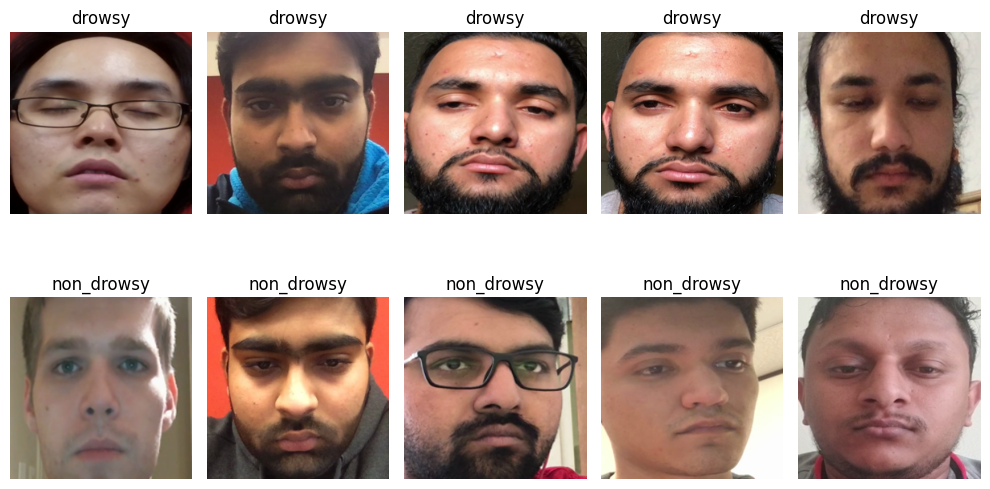

In [21]:
class_names = ['drowsy', 'non_drowsy']
plt.figure(figsize=(10, 6))
idx = 1
TRAIN_DIR =DATASET_DIR / 'dataset/train/'
TEST_DIR = DATASET_DIR / 'dataset/test/'
for cls in class_names:
    for img_path in list((TRAIN_DIR / cls).glob('*'))[:5]:
        img = cv2.imread(str(img_path))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 5, idx)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')
        idx += 1
plt.tight_layout()
plt.show()

## 5. Optional Face Detection and Cropping

The dataset already contains face images, but real camera frames may include background. Face detection helps the model focus on eyes, mouth, facial posture, and head angle.

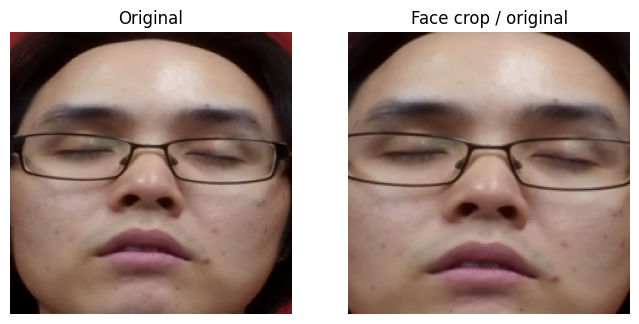

In [22]:
def crop_face_opencv(image_rgb):
    """Return cropped face if detected; otherwise return original image."""
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    detector = cv2.CascadeClassifier(cascade_path)
    faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    if len(faces) == 0:
        return image_rgb
    x, y, w, h = max(faces, key=lambda box: box[2] * box[3])
    return image_rgb[y:y+h, x:x+w]

sample_path = next((TRAIN_DIR / 'drowsy').glob('*'))
img = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
cropped = crop_face_opencv(img)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cropped); plt.title('Face crop / original'); plt.axis('off')
plt.show()

## 6. Create Training, Validation, and Test Datasets

Images are resized to `128 × 128`. MobileNetV2 preprocessing is applied inside the model.

In [23]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='binary', shuffle=False)

print('Class names:', train_ds.class_names)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 7500 files belonging to 2 classes.
Using 6000 files for training.
Found 7500 files belonging to 2 classes.
Using 1500 files for validation.
Found 2500 files belonging to 2 classes.
Class names: ['drowsy', 'non_drowsy']


## 7. Data Augmentation

This improves robustness to lighting changes, shadows, camera distance, and head tilt.

In [24]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.15),
], name='data_augmentation')

## 8. Build MobileNetV2 Transfer Learning Model

Training uses two phases: frozen base model first, then fine-tuning with a smaller learning rate.

In [25]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 9. Phase 1 Training: Frozen Base Model

In [26]:
checkpoint_path = '/content/best_drowsiness_model.keras'
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)
]

history_phase1 = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 35s 117ms/step - accuracy: 0.8122 - loss: 0.3928 - precision: 0.8147 - recall: 0.8079 - val_accuracy: 0.9367 - val_loss: 0.1966 - val_precision: 0.9271 - val_recall: 0.9481 - learning_rate: 0.0010
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 31s 103ms/step - accuracy: 0.9267 - loss: 0.1942 - precision: 0.9292 - recall: 0.9236 - val_accuracy: 0.9467 - val_loss: 0.1526 - val_precision: 0.9147 - val_recall: 0.9854 - learning_rate: 0.0010
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.9523 - loss: 0.1352 - precision: 0.9514 - recall: 0.9533 - val_accuracy: 0.9613 - val_loss: 0.1027 - val_precision: 0.9664 - val_recall: 0.9561 - learning_rate: 0.0010
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.9683 - loss: 0.0910 - precision: 0.9686 - recall: 0.9680 - val_accuracy: 0.9827 - val_loss: 0.0622 - val_precision: 0.9853 - val_recall: 0.9800 - learning_rate: 0.0010
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step

## 10. Phase 2 Training: Fine-Tuning

In [27]:
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
)

history_phase2 = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 116ms/step - accuracy: 0.7395 - loss: 1.0945 - precision: 0.8693 - recall: 0.5635 - val_accuracy: 0.9820 - val_loss: 0.0511 - val_precision: 0.9986 - val_recall: 0.9654 - learning_rate: 1.0000e-05
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.8915 - loss: 0.3350 - precision: 0.9196 - recall: 0.8580 - val_accuracy: 0.9753 - val_loss: 0.0644 - val_precision: 0.9986 - val_recall: 0.9521 - learning_rate: 1.0000e-05
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.9225 - loss: 0.2192 - precision: 0.9295 - recall: 0.9143 - val_accuracy: 0.9627 - val_loss: 0.0874 - val_precision: 0.9971 - val_recall: 0.9281 - learning_rate: 3.0000e-06
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.9255 - loss: 0.2203 - precision: 0.9364 - recall: 0.9130 - val_accuracy: 0.9453 - val_loss: 0.1377 - val_precision: 0.9941 - val_recall: 0.8961 - learning_rate: 3.0000e-06
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━

## 11. Plot Training Curves

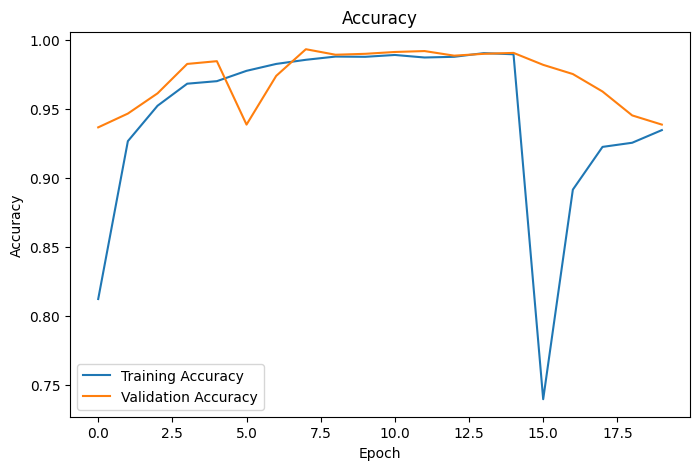

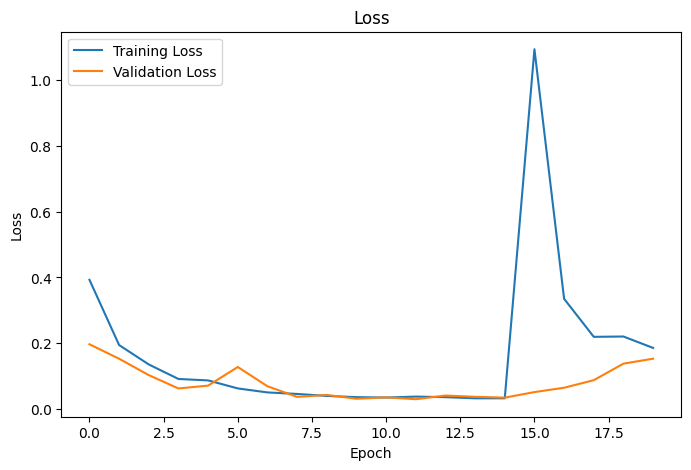

In [28]:
def combine_history(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc = combine_history(history_phase1, history_phase2, 'accuracy')
val_acc = combine_history(history_phase1, history_phase2, 'val_accuracy')
loss = combine_history(history_phase1, history_phase2, 'loss')
val_loss = combine_history(history_phase1, history_phase2, 'val_loss')

plt.figure(figsize=(8,5))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss')
plt.show()

## 12. Evaluate on Test Set

For a safety system, drowsy-class recall is critical because missing a drowsy driver is dangerous.

Class names: ['drowsy', 'non_drowsy']
Accuracy: 0.9948
Precision: 0.997586484312148
Recall: 0.992
F1-score: 0.9947853991175291
Classification Report:
              precision    recall  f1-score   support

      drowsy       0.99      1.00      0.99      1250
  non_drowsy       1.00      0.99      0.99      1250

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



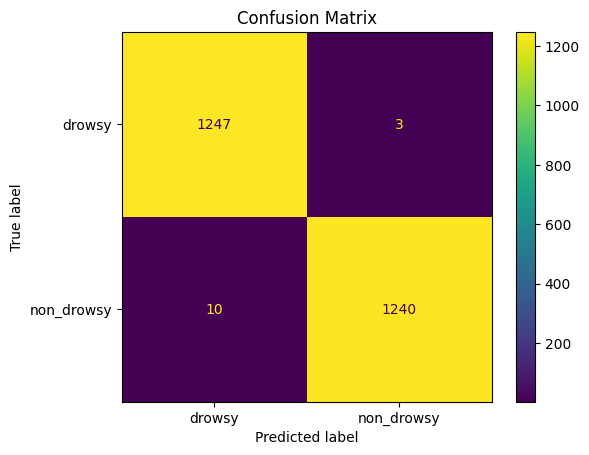

In [34]:
model = keras.models.load_model(checkpoint_path)

# Use saved class_names if already created earlier.
# If not, set it manually based on your folder names:
class_names = ["drowsy", "non_drowsy"]

y_true, y_prob = [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0).ravel()
    y_prob.extend(probs)
    y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

print("Class names:", class_names)
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-score:", f1_score(y_true, y_pred))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

## 13. Threshold Tuning

The default threshold is `0.5`. For a safety system, tune the threshold to reduce missed drowsy cases.

In [35]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_prob >= threshold).astype(int)
    print(f'Threshold = {threshold}')
    print('Accuracy:', round(accuracy_score(y_true, y_pred_t), 4))
    print('Precision:', round(precision_score(y_true, y_pred_t), 4))
    print('Recall:', round(recall_score(y_true, y_pred_t), 4))
    print('F1:', round(f1_score(y_true, y_pred_t), 4))

Threshold = 0.3
Accuracy: 0.9936
Precision: 0.9889
Recall: 0.9984
F1: 0.9936
Threshold = 0.4
Accuracy: 0.9956
Precision: 0.996
Recall: 0.9952
F1: 0.9956
Threshold = 0.5
Accuracy: 0.9948
Precision: 0.9976
Recall: 0.992
F1: 0.9948
Threshold = 0.6
Accuracy: 0.994
Precision: 0.9984
Recall: 0.9896
F1: 0.994
Threshold = 0.7
Accuracy: 0.9916
Precision: 0.9992
Recall: 0.984
F1: 0.9915


## 14. Individual Image Prediction

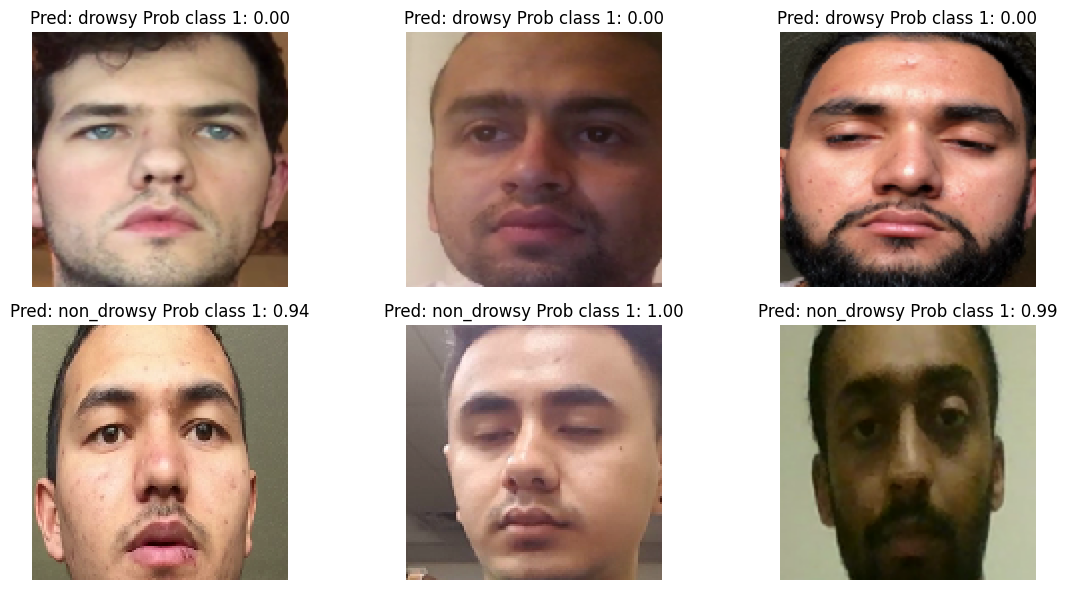

In [38]:
# Define class names manually or use the saved variable from earlier
class_names = ["drowsy", "non_drowsy"]

def predict_image(image_path, threshold=0.5):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)

    prob = model.predict(arr, verbose=0)[0][0]
    pred_idx = int(prob >= threshold)

    return class_names[pred_idx], float(prob)

sample_images = list((TEST_DIR/'drowsy').glob('*'))[:3] + list((TEST_DIR/'non_drowsy').glob('*'))[:3]
plt.figure(figsize=(12,6))
for i, img_path in enumerate(sample_images, 1):
    pred_class, prob = predict_image(str(img_path))
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    plt.subplot(2,3,i)
    plt.imshow(img)
    plt.title(f'Pred: {pred_class} Prob class 1: {prob:.2f}')
    plt.axis('off')
plt.tight_layout(); plt.show()

## 15. Save Model and Convert to TensorFlow Lite

In [39]:
model.save('/content/driver_drowsiness_mobilenetv2.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
open('/content/driver_drowsiness_model.tflite', 'wb').write(tflite_model)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
quantized_tflite_model = converter.convert()
open('/content/driver_drowsiness_model_quantized.tflite', 'wb').write(quantized_tflite_model)

print('Keras MB:', os.path.getsize('/content/driver_drowsiness_mobilenetv2.keras')/(1024*1024))
print('TFLite MB:', os.path.getsize('/content/driver_drowsiness_model.tflite')/(1024*1024))
print('Quantized TFLite MB:', os.path.getsize('/content/driver_drowsiness_model_quantized.tflite')/(1024*1024))

Saved artifact at '/tmp/tmppga9fjn2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134124746496656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134124746494352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134124746497424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134124746497232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134124746494160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134124746496272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134124746492048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134124746491472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134124746496464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134124746495888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1341247464922

## 16. TFLite Inference Demo

In [41]:
def tflite_predict(image_path, tflite_path="/content/driver_drowsiness_model_quantized.tflite"):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]["index"], arr)
    interpreter.invoke()

    return float(interpreter.get_tensor(output_details[0]["index"]).ravel()[0])


class_names = ["drowsy", "non_drowsy"]

sample_path = str(next((TEST_DIR / "drowsy").glob("*")))

prob = tflite_predict(sample_path)

print("TFLite probability for class 1:", prob)
print("Predicted class:", class_names[int(prob >= 0.5)])

TFLite probability for class 1: 0.001292184111662209
Predicted class: drowsy


# **1. Why not start from scratch?**

Training a deep learning model completely from scratch would not be the best choice here because the dataset is relatively small. Deep CNN models usually require a huge amount of data and training time to learn useful image features properly. With limited data, the model can easily memorize the training images instead of learning general patterns, which leads to overfitting.

Using Transfer Learning with MobileNetV2 is a smarter approach because the model has already been trained on millions of images. It already understands basic visual features like edges, shapes, textures, and facial structures, so we only need to fine-tune it for drowsiness detection.

# **2. The cost of missing a drowsy driver**

Failing to detect a drowsy driver is far more dangerous than giving a false warning to an alert driver. A false alarm may only cause temporary inconvenience or irritation, but missing a truly drowsy driver could result in a serious road accident.

Because of this, recall becomes a very important metric in this project. High recall ensures that most drowsy drivers are correctly identified by the system.

# **3. Seeing in the dark**

Lighting conditions inside a vehicle can change a lot depending on the time of day, weather, or road environment. If the model is trained only on clear and bright images, it may struggle during night driving or under shadows.

To handle this, data augmentation techniques such as brightness adjustment, rotation, zooming, and flipping were used. These augmentations help the model learn from different visual conditions and improve its performance in real-world driving situations.

# **4. Why detect the face first?**

The camera frame may contain many unnecessary objects like the steering wheel, dashboard, windows, or background scenery. These extra details do not help in identifying drowsiness and may confuse the model.

By detecting and cropping only the driver’s face, the model can focus on important facial features such as eye closure, head position, and facial expressions. This improves both accuracy and efficiency.

# **5. Shrinking the model for the road**

Since the model is intended to run on edge devices like in-vehicle cameras or Raspberry Pi systems, the model needs to be lightweight and fast. TensorFlow Lite conversion helps reduce the model size and makes inference faster on low-power devices.

Quantization can further compress the model by reducing numerical precision. The trade-off is that there may be a slight reduction in prediction accuracy, but the improvement in speed and memory usage makes it suitable for real-time deployment.

# **6. Training in two phases**

The model was trained in two stages to make learning more stable and effective. In the first phase, the pre-trained MobileNetV2 layers were frozen and only the custom classification layers were trained. This allows the model to adapt to the new task without disturbing the useful pre-trained features.

In the second phase, some of the deeper layers were unfrozen and fine-tuned using a smaller learning rate. This helps the model improve performance gradually while avoiding large weight updates that could damage previously learned features.

# **7. Beyond just accuracy**

Accuracy alone cannot fully describe the performance of a safety-critical system like driver drowsiness detection. A model may achieve high accuracy simply by predicting the majority class more often, while still failing to detect important drowsy cases.

That is why additional metrics such as precision, recall, F1-score, and confusion matrix analysis are necessary. These metrics provide a better understanding of how well the system identifies drowsy drivers and where mistakes are occurring.

# **8. Improving the model**

If the model still misses some drowsy drivers, one practical improvement would be collecting more diverse training images, especially under low-light conditions, different camera angles, and varied facial appearances. Better data usually leads to better generalization.

Another improvement would be adjusting the confidence threshold or applying stronger augmentation and class balancing techniques. This can help the model become more sensitive to drowsiness-related features and improve recall.

# **9. Actionable advice**

The detection system should not stop at prediction alone. Once drowsiness is detected, the system should immediately trigger an alert such as a sound warning or vibration to wake the driver.

For commercial transport systems, repeated drowsiness alerts can also be logged and shared with fleet management teams. This allows companies to monitor driver safety, recommend rest breaks, and reduce accident risks proactively.